# Instructions
- Make a copy of this notebook in your drive.
- Load the **Netflix Movies and TV Shows dataset**.
- Read through each step and run the cells in order.
- Do not skip steps; each one builds on the previous one.
- Add your own observations wherever possible, especially when exploring graphs.
- This is practice for real-world data preprocessing and EDA, so think about *why* each step is done, not just *how*.
- At the end, feel free to explore further and add more plots, groupbys, or questions of your own.

Welcome to this checkpoint task.

Today we are exploring the Netflix Movies and TV Shows dataset to practice data preprocessing and exploratory data analysis (EDA). Think of the dataset as a big streaming catalogue that needs sorting before it is ready to be recommended to viewers - we will clean it, organize it, and look for patterns worth noticing.

We will be using pandas, numpy, matplotlib, and seaborn for this task.

Run the following cell to import them.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Setting the Scene

Before analyzing anything, we need to bring the dataset into our workspace.

**Your task:**
- Load the dataset into a pandas DataFrame.
- Look at the first few rows to see what the data contains.
- Check the shape of the dataset - how many titles and how many columns are we working with?

Think of this as opening the catalogue for the first time and getting a feel for its size.

In [4]:
df=pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [7]:
print("Number of Titles:", df.shape[0])

print("Number of Columns:", df.shape[1])

Number of Titles: 8807
Number of Columns: 12


### Level 1: Know Your Columns

Every dataset has its own structure - some columns hold text, some hold numbers, and some may be incomplete.

**Your task:**
- Get a quick overview of column types and how many missing values each column has.
- Double-check that each column's data type makes sense for what it represents.

This is like reading the label on each shelf before you start organizing it.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### Level 2: Quick Stats Check

Before diving deeper, it helps to see a summary of the numerical columns.

**Your task:**
- Get summary statistics for the numerical columns.
- Note things like the earliest and most recent release years, and how the values are spread out.

This step gives you a first impression of the range and scale of the data.

In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Level 3: Clean the Catalogue (Missing Values)

Some entries in a streaming catalogue are incomplete, and we need to decide how to handle that.

**Your tasks:**
- Check how many missing values are in each column.
- For this dataset, handle missing values in **`director`** and **`country`** by removing those rows.
- Re-check to confirm there are no missing values left in those two columns.

> Tip: Do a quick sanity check after cleaning - the row count should drop a bit.

In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [27]:
df = df.dropna(subset=["director", "country"])
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,415
country,0
date_added,0
release_year,0
rating,1
duration,3


## Level 4: Fix the `date_added` Column (Data Types)

The `date_added` column is usually stored as plain text, which makes it hard to work with dates properly.

**Your tasks:**
- Convert **`date_added`** to a proper datetime type.
- Create a new column called **`year_added`** that extracts just the year from `date_added`.
- Run a quick `info()` check to confirm the changes.

> If the conversion produces errors, check for stray spaces or unexpected formats in the column first.

In [23]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

df["year_added"] = df["date_added"].dt.year

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5751 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5751 non-null   object        
 1   type          5751 non-null   object        
 2   title         5751 non-null   object        
 3   director      5751 non-null   object        
 4   cast          5336 non-null   object        
 5   country       5751 non-null   object        
 6   date_added    5751 non-null   datetime64[ns]
 7   release_year  5751 non-null   int64         
 8   rating        5750 non-null   object        
 9   duration      5748 non-null   object        
 10  listed_in     5751 non-null   object        
 11  description   5751 non-null   object        
 12  year_added    5751 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 606.6+ KB


## Level 5: The Longest Watches

Some titles run much longer than others. Let's find the standouts.

**Your task:**
- List the **Top 5 longest movies** in the dataset.
- Display their **title, country, release_year, and duration**.

Think of this as building a short list for viewers who want an epic movie night.

In [28]:
movies = df[df["type"] == "Movie"].copy()

movies["duration_min"] = movies["duration"].str.extract(r"(\d+)").astype(float)

longest_movies = movies.sort_values(
    by="duration_min",
    ascending=False
).head(5)

longest_movies[["title", "country", "release_year", "duration"]]

,title,country,release_year,duration
2491,The School of Mischief,Egypt,1973,253 min
2487,No Longer kids,Egypt,1979,237 min
166,Once Upon a Time in America,"Italy, United States",1984,229 min
7932,Sangam,India,1964,228 min
1019,Lagaan,"India, United Kingdom",2001,224 min


## Level 6: Movies vs TV Shows

The catalogue contains two kinds of content: movies and TV shows.

**Your task:**
- Count how many titles fall into each `type` category.
- Create a bar chart to visualize the counts.
- Answer: which type makes up the larger share of the catalogue?

In [25]:
type_counts = df["type"].value_counts()

print(type_counts)

type
Movie      5562
TV Show     189
Name: count, dtype: int64


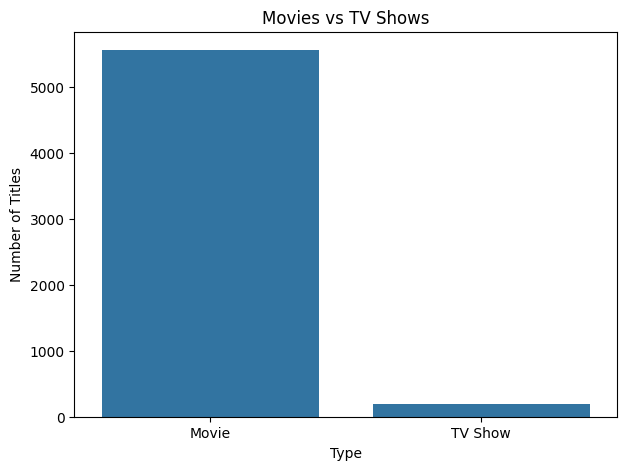

In [26]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Number of Titles")

plt.show()

## Level 7: Where Does the Content Come From?

Netflix sources content from many countries.

**Your task:**
- Find the **Top 5 countries** with the highest number of titles.
- Show their contribution using a pie chart.

This will help us see which countries dominate the catalogue.

In [29]:
country_data = df.copy()

country_data["country"] = country_data["country"].str.split(", ")

country_data = country_data.explode("country")

country_counts = country_data["country"].value_counts()

top_5_countries = country_counts.head(5)

top_5_countries

,count
country,
United States,2749
India,961
United Kingdom,537
Canada,317
France,311


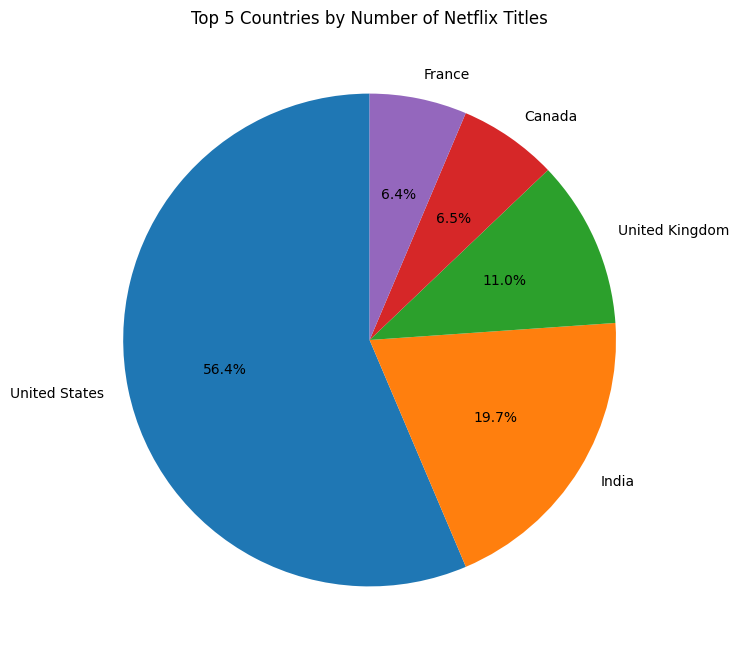

In [30]:
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_countries.values,
    labels=top_5_countries.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Countries by Number of Netflix Titles")

plt.show()

## Level 8: Genre Leaders by Country

Different genres may be led by different countries.

**Your task:**
- For each genre in `listed_in`, find the **country** that has produced the most titles in that genre.
- Print the results as a list (Genre -> Leading Country).

> Note: a title can belong to more than one genre - think about how you want to handle that before grouping.

In [31]:
genre_country = df[["listed_in", "country"]].copy()

genre_country["listed_in"] = genre_country["listed_in"].str.split(", ")
genre_country["country"] = genre_country["country"].str.split(", ")

genre_country = genre_country.explode("listed_in")
genre_country = genre_country.explode("country")

genre_country_counts = (
    genre_country
    .groupby(["listed_in", "country"])
    .size()
    .reset_index(name="count")
)

genre_country_counts = genre_country_counts.sort_values(
    ["listed_in", "count"],
    ascending=[True, False]
)

leading_countries = genre_country_counts.drop_duplicates(
    subset="listed_in"
)

for index, row in leading_countries.iterrows():
    print(row["listed_in"], "->", row["country"])

Action & Adventure -> United States
Anime Features -> Japan
Anime Series -> Japan
British TV Shows -> United Kingdom
Children & Family Movies -> United States
Classic & Cult TV -> United Kingdom
Classic Movies -> United States
Comedies -> United States
Crime TV Shows -> United States
Cult Movies -> United States
Documentaries -> United States
Docuseries -> United States
Dramas -> United States
Faith & Spirituality -> United States
Horror Movies -> United States
Independent Movies -> United States
International Movies -> India
International TV Shows -> Spain
Kids' TV -> United States
Korean TV Shows -> South Korea
LGBTQ Movies -> United States
Movies -> United States
Music & Musicals -> United States
Reality TV -> Brazil
Romantic Movies -> United States
Romantic TV Shows -> South Korea
Sci-Fi & Fantasy -> United States
Science & Nature TV -> Brazil
Spanish-Language TV Shows -> Spain
Sports Movies -> United States
Stand-Up Comedy -> United States
Stand-Up Comedy & Talk Shows -> United St

## Level 9: Netflix's Busiest Year

Netflix has grown its catalogue steadily over the years, but some years stand out more than others.

**Your task:**
- Group the data by `year_added`.
- Find the year in which Netflix added the **most titles** to its catalogue.

This shows us the point where the platform's library grew the fastest.

In [34]:
year_counts = df["year_added"].value_counts()

busiest_year = year_counts.idxmax()
most_titles = year_counts.max()

print("Busiest year:", busiest_year)
print("Number of titles added:", most_titles)
year_counts.sort_values(ascending=False).head()

Busiest year: 2019
Number of titles added: 1352


,count
year_added,
2019,1352
2020,1256
2018,1175
2017,830
2021,797


## Final Task: Open Exploration

You have worked through each step above - now it's time to explore on your own.

**Your final task:**
- Choose any 2 to 3 plots of your own choice that reveal an interesting pattern in the data.

This is your creative zone - treat it as building your own short story from the dataset. When you are done, share your best plot and the observation behind it with the group.

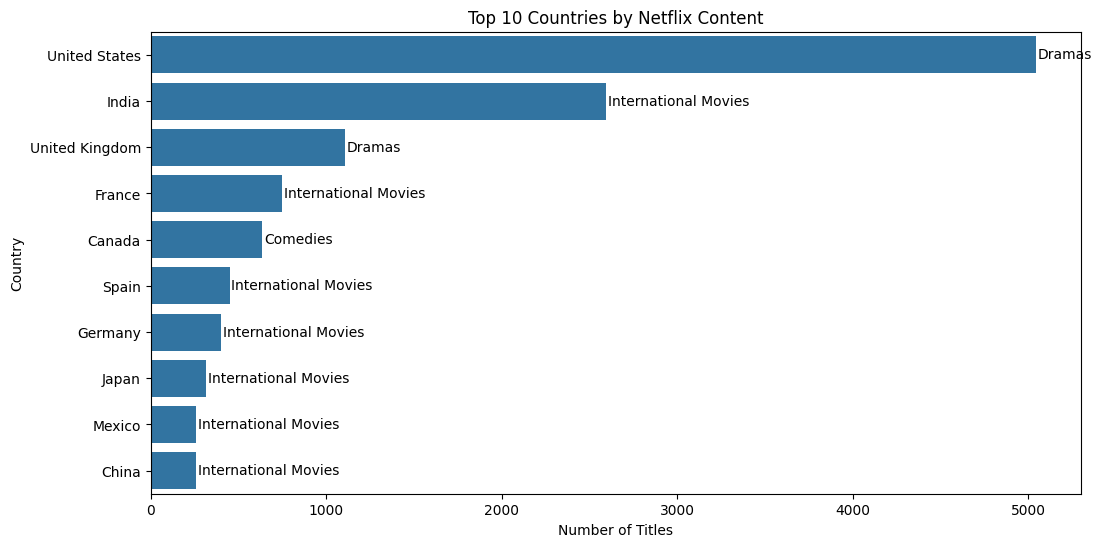

In [35]:
# PLOT 1
country_genre = df[["country", "listed_in"]].dropna().copy()

country_genre["country"] = country_genre["country"].str.split(", ")
country_genre["listed_in"] = country_genre["listed_in"].str.split(", ")

country_genre = country_genre.explode("country")
country_genre = country_genre.explode("listed_in")

top_countries = country_genre["country"].value_counts().head(10)

top_genres = (
    country_genre[country_genre["country"].isin(top_countries.index)]
    .groupby(["country", "listed_in"])
    .size()
    .reset_index(name="count")
    .sort_values(["country", "count"], ascending=[True, False])
    .drop_duplicates("country")
)

plt.figure(figsize=(12, 6))

bars = sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

for bar, country in zip(bars.patches, top_countries.index):
    genre = top_genres[top_genres["country"] == country]["listed_in"].iloc[0]
    plt.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height()/2,
        genre,
        va="center"
    )

plt.show()

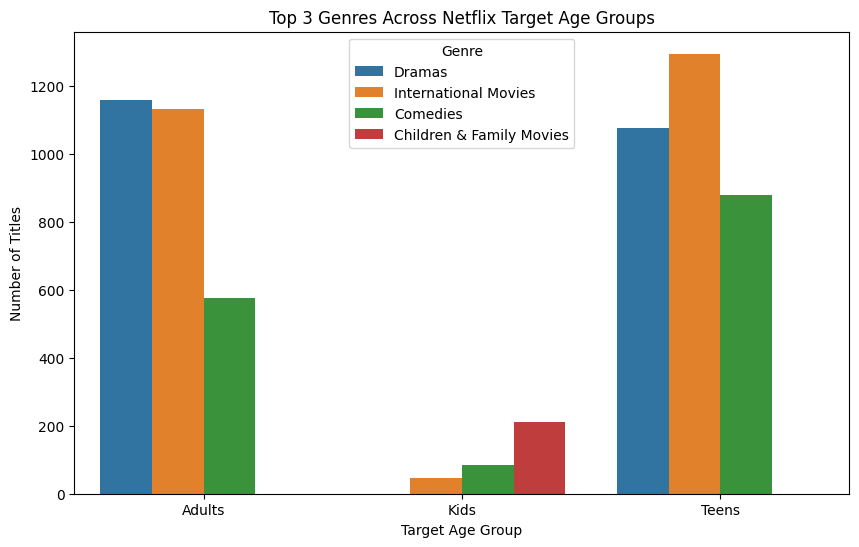

In [36]:
rating_age = {
    "TV-Y": "Kids",
    "TV-Y7": "Kids",
    "TV-Y7-FV": "Kids",
    "TV-G": "Kids",
    "G": "Kids",
    "TV-PG": "Teens",
    "PG": "Teens",
    "PG-13": "Teens",
    "TV-14": "Teens",
    "R": "Adults",
    "TV-MA": "Adults",
    "NC-17": "Adults"
}

age_data = df[["rating", "listed_in"]].dropna().copy()

age_data["age_group"] = age_data["rating"].map(rating_age)

age_data["listed_in"] = age_data["listed_in"].str.split(", ")
age_data = age_data.explode("listed_in")

age_counts = age_data["age_group"].value_counts()

top_3_genres = (
    age_data.groupby(["age_group", "listed_in"])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["age_group", "count"],
        ascending=[True, False]
    )
)

top_3_genres = top_3_genres.groupby("age_group").head(3)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_3_genres,
    x="age_group",
    y="count",
    hue="listed_in"
)

plt.title("Top 3 Genres Across Netflix Target Age Groups")
plt.xlabel("Target Age Group")
plt.ylabel("Number of Titles")
plt.legend(title="Genre")

plt.show()

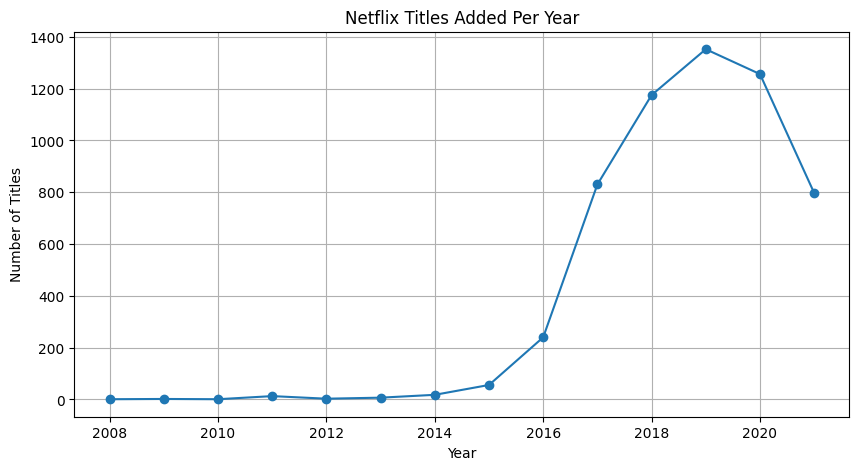

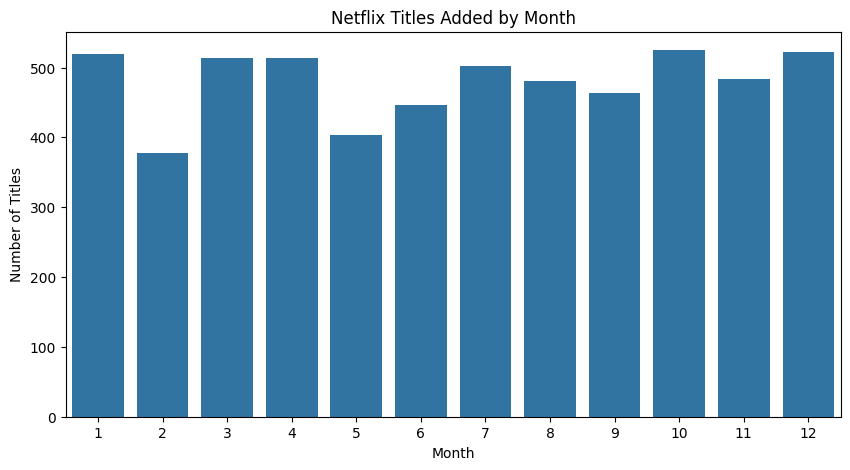

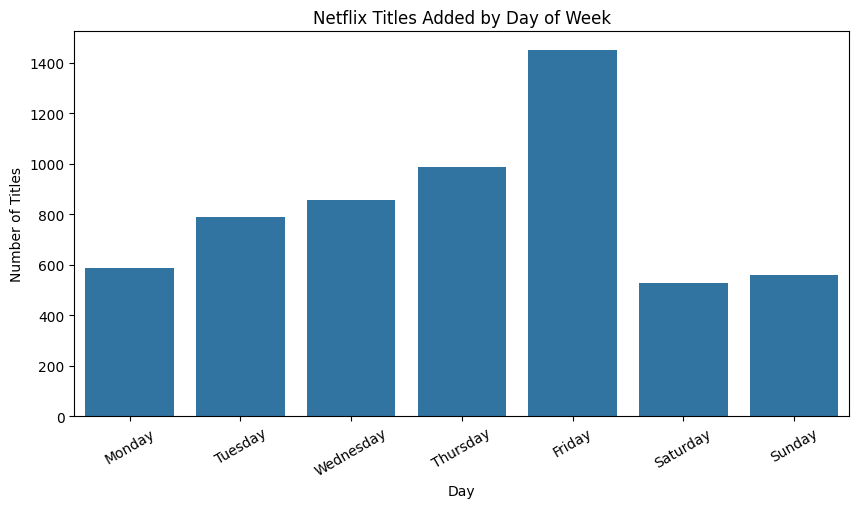

In [37]:
df["month_added"] = df["date_added"].dt.month
df["day_added"] = df["date_added"].dt.day_name()

monthly_counts = df["month_added"].value_counts().sort_index()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_counts = df["day_added"].value_counts().reindex(weekday_order)

yearly_counts = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_counts.index,
    yearly_counts.values,
    marker="o"
)

plt.title("Netflix Titles Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.show()


plt.figure(figsize=(10, 5))

sns.barplot(
    x=monthly_counts.index,
    y=monthly_counts.values
)

plt.title("Netflix Titles Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.show()


plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_counts.index,
    y=weekday_counts.values
)

plt.title("Netflix Titles Added by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Titles")

plt.xticks(rotation=30)

plt.show()